## 0. Install libraries

In [28]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and clean dataset 

In [30]:
file_path = '/kaggle/input/competitions/pokemon-tcg-ai-battle/EN_Card_Data.csv'

print(f"Loading data from: {file_path}")

try:
    df = pd.read_csv(file_path)
    
    # Clean column names (strip whitespaces)
    df.columns = df.columns.str.strip()
    
    # Clean string columns (strip trailing spaces from values)
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.strip()
        # Replace 'n/a', 'nan', 'None' with actual NaNs
        df[col] = df[col].replace({'n/a': np.nan, 'nan': np.nan, 'None': np.nan})
        
    print(f"Dataset loaded successfully. Shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")

Loading data from: /kaggle/input/competitions/pokemon-tcg-ai-battle/EN_Card_Data.csv
Dataset loaded successfully. Shape: (2022, 17)


## 2. Dataset Overview

In [31]:
df.info()  # Display dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2022 entries, 0 to 2021
Data columns (total 17 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Card ID                                    2022 non-null   int64  
 1   Card Name                                  2022 non-null   object 
 2   Expansion                                  2012 non-null   object 
 3   Collection No.                             2022 non-null   int64  
 4   Stage (Pokémon)/Type (Energy and Trainer)  2022 non-null   object 
 5   Rule                                       353 non-null    object 
 6   Category                                   392 non-null    object 
 7   Previous stage                             857 non-null    object 
 8   HP                                         1815 non-null   float64
 9   Type                                       1825 non-null   object 
 10  Weakness                

In [32]:
df.head()

,Card ID,Card Name,Expansion,Collection No.,Stage (Pokémon)/Type (Energy and Trainer),Rule,Category,Previous stage,HP,Type,Weakness,Resistance (Type),Retreat,Move Name,Cost,Damage,Effect Explanation
0,1,Basic {G} Energy,SVE,1,Basic Energy,NaN,NaN,NaN,NaN,{G},NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Basic {R} Energy,SVE,2,Basic Energy,NaN,NaN,NaN,NaN,{R},NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Basic {W} Energy,SVE,3,Basic Energy,NaN,NaN,NaN,NaN,{W},NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Basic {L} Energy,SVE,4,Basic Energy,NaN,NaN,NaN,NaN,{L},NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Basic {P} Energy,SVE,5,Basic Energy,NaN,NaN,NaN,NaN,{P},NaN,NaN,NaN,NaN,NaN,NaN,NaN


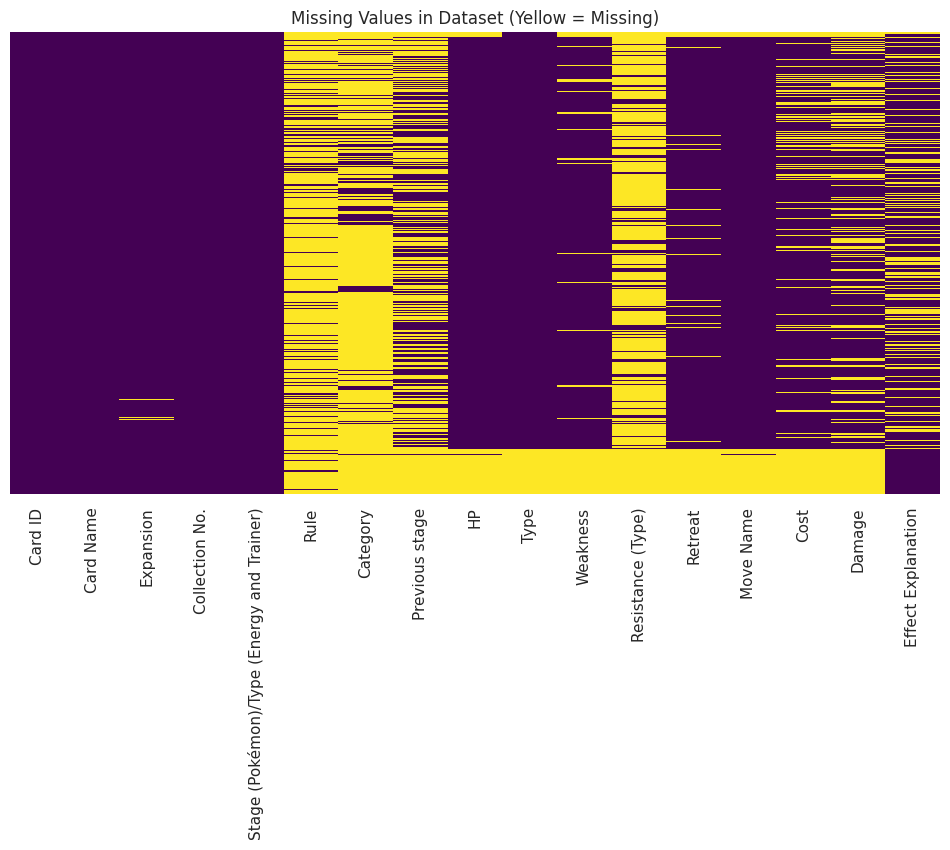

Missing Values per Column:
Expansion               10
Rule                  1669
Category              1630
Previous stage        1165
HP                     207
Type                   197
Weakness               288
Resistance (Type)     1646
Retreat                274
Move Name              211
Cost                   466
Damage                 737
Effect Explanation     541
dtype: int64


In [33]:
# Visualizing missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values in Dataset (Yellow = Missing)')
plt.show()

missing_counts = df.isnull().sum()
print("Missing Values per Column:")
print(missing_counts[missing_counts > 0])

## 3. Card Categories Distribution

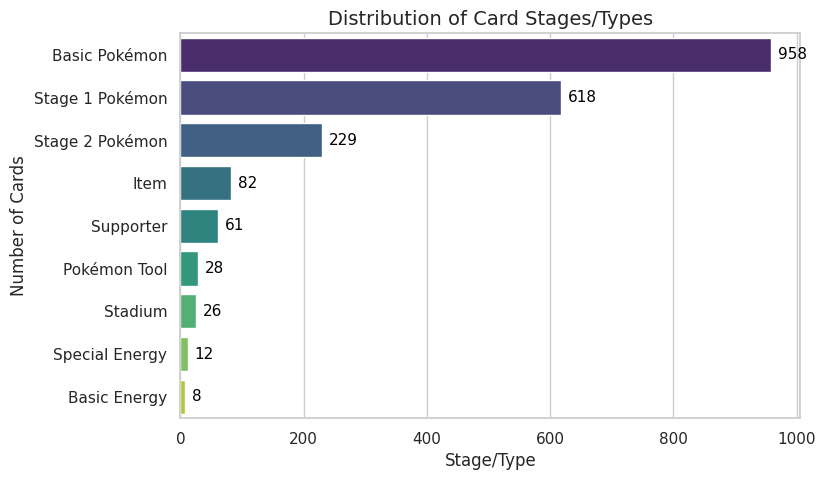

In [34]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, y='Stage (Pokémon)/Type (Energy and Trainer)', order=df['Stage (Pokémon)/Type (Energy and Trainer)'].value_counts().index, palette='viridis')
plt.title('Distribution of Card Stages/Types', fontsize=14)
plt.ylabel('Number of Cards')
plt.xlabel('Stage/Type')

# Add data labels
for p in ax.patches:
    width = p.get_width()
    # Check to ensure the bar has a valid value
    if width > 0:
        ax.annotate(
            f'{int(width)}', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left',          # Align text to the left of the coordinate
            va='center',        # Center vertically on the bar
            fontsize=11, 
            color='black', 
            xytext=(5, 0),      # Offset slightly to the right of the bar edge
            textcoords='offset points'
        )
plt.show()

In [35]:
# Count the occurrences of each keyword
pokemon_count = df['Stage (Pokémon)/Type (Energy and Trainer)'].str.contains('Basic Pokémon|Stage 1 Pokémon|Stage 2 Pokémon', case=False, na=False).sum()
energy_count = df['Stage (Pokémon)/Type (Energy and Trainer)'].str.contains('Energy', case=False, na=False).sum()
trainer_count = df['Stage (Pokémon)/Type (Energy and Trainer)'].str.contains('Item|Stadium|Supporter|Pokémon Tool', case=False, na=False).sum()

print(f"Pokémon count: {pokemon_count}")
print(f"Energy count: {energy_count}")
print(f"Trainer count: {trainer_count}")

Pokémon count: 1805
Energy count: 20
Trainer count: 197


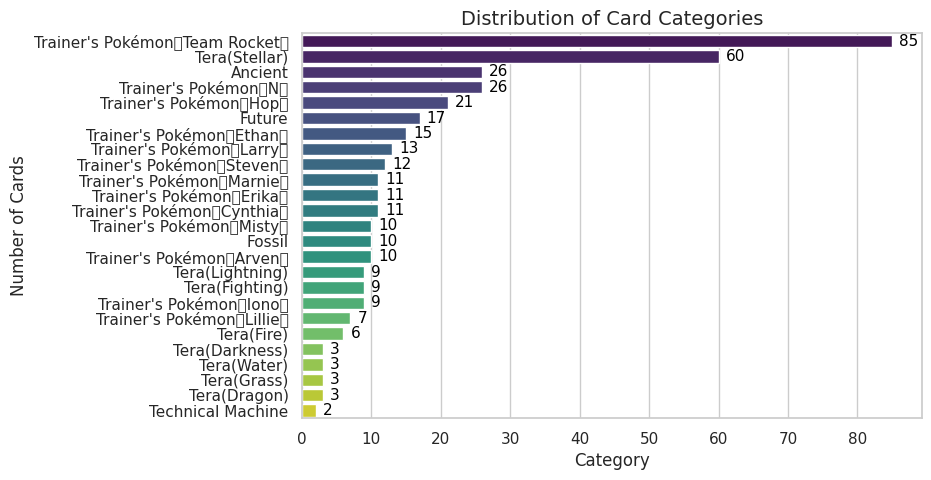

In [36]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, y='Category', order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribution of Card Categories', fontsize=14)
plt.ylabel('Number of Cards')
plt.xlabel('Category')

# Add data labels
for p in ax.patches:
    width = p.get_width()
    # Check to ensure the bar has a valid value
    if width > 0:
        ax.annotate(
            f'{int(width)}', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left',          # Align text to the left of the coordinate
            va='center',        # Center vertically on the bar
            fontsize=11, 
            color='black', 
            xytext=(5, 0),      # Offset slightly to the right of the bar edge
            textcoords='offset points'
        )
plt.show()

## 4. Pokémon Cards Analysis

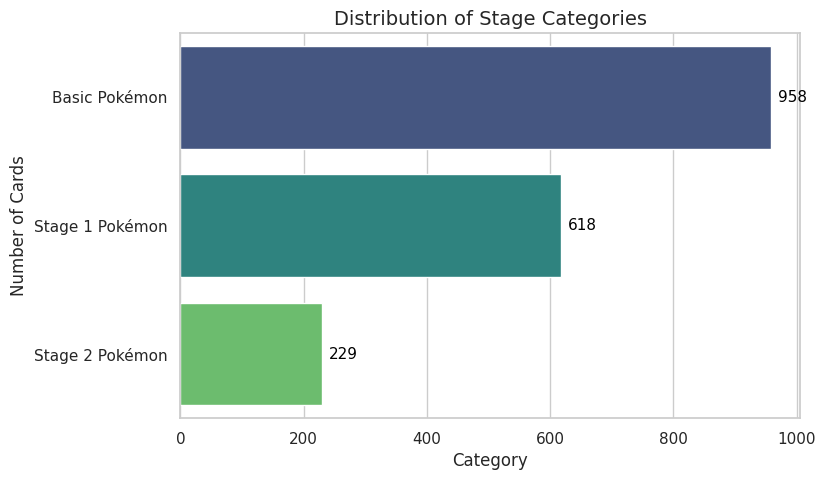

In [37]:
pokemon_df = df[df['Stage (Pokémon)/Type (Energy and Trainer)'].str.contains('Basic Pokémon|Stage 1 Pokémon|Stage 2 Pokémon', case=False, na=False)].copy()

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=pokemon_df, y='Stage (Pokémon)/Type (Energy and Trainer)', order=pokemon_df['Stage (Pokémon)/Type (Energy and Trainer)'].value_counts().index, palette='viridis')
plt.title('Distribution of Stage Categories', fontsize=14)
plt.ylabel('Number of Cards')
plt.xlabel('Category')

# Add data labels
for p in ax.patches:
    width = p.get_width()
    # Check to ensure the bar has a valid value
    if width > 0:
        ax.annotate(
            f'{int(width)}', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left',          # Align text to the left of the coordinate
            va='center',        # Center vertically on the bar
            fontsize=11, 
            color='black', 
            xytext=(5, 0),      # Offset slightly to the right of the bar edge
            textcoords='offset points'
        )
plt.show()

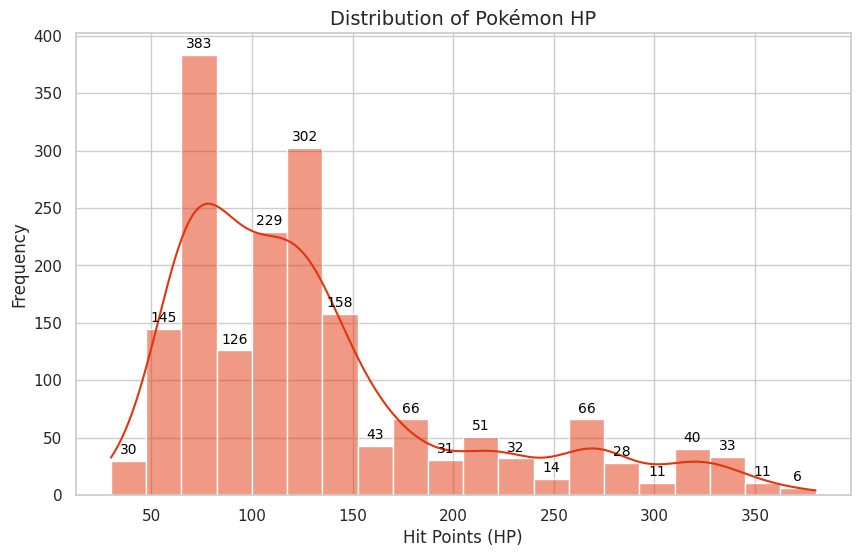

Average HP: 131.7
Max HP: 380


In [38]:
# Clean HP: Extract numeric part (e.g., in case there's '120 HP')
pokemon_df['HP_Num'] = pd.to_numeric(pokemon_df['HP'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# Capture the axis object (ax) from the histplot
ax = sns.histplot(pokemon_df['HP_Num'].dropna(), bins=20, kde=True, color='#E3350D')
plt.title('Distribution of Pokémon HP', fontsize=14)
plt.xlabel('Hit Points (HP)')
plt.ylabel('Frequency')

# Add data labels to the histogram bars
for p in ax.patches:
    height = p.get_height()
    # Only add a label if the bin has data and it's an actual bar patch
    if height > 0 and p.get_width() > 0:
        ax.annotate(
            f'{int(height)}', 
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='baseline', 
            fontsize=10, 
            color='black', 
            xytext=(0, 5), 
            textcoords='offset points'
        )
plt.show()

# Print summary stats
print(f"Average HP: {pokemon_df['HP_Num'].mean():.1f}")
print(f"Max HP: {pokemon_df['HP_Num'].max()}")

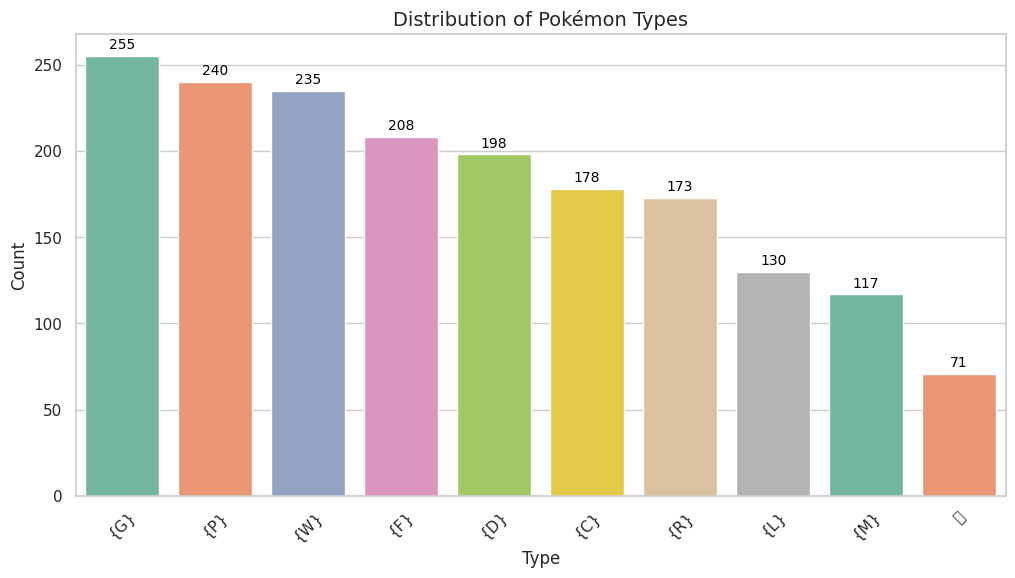

In [39]:
plt.figure(figsize=(12, 6))
type_counts = pokemon_df['Type'].value_counts()
ax=sns.barplot(x=type_counts.index, y=type_counts.values, palette='Set2')
plt.title('Distribution of Pokémon Types', fontsize=14)
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
# Add data labels to the histogram bars
for p in ax.patches:
    height = p.get_height()
    # Only add a label if the bin has data and it's an actual bar patch
    if height > 0 and p.get_width() > 0:
        ax.annotate(
            f'{int(height)}', 
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='baseline', 
            fontsize=10, 
            color='black', 
            xytext=(0, 5), 
            textcoords='offset points'
        )
plt.show()

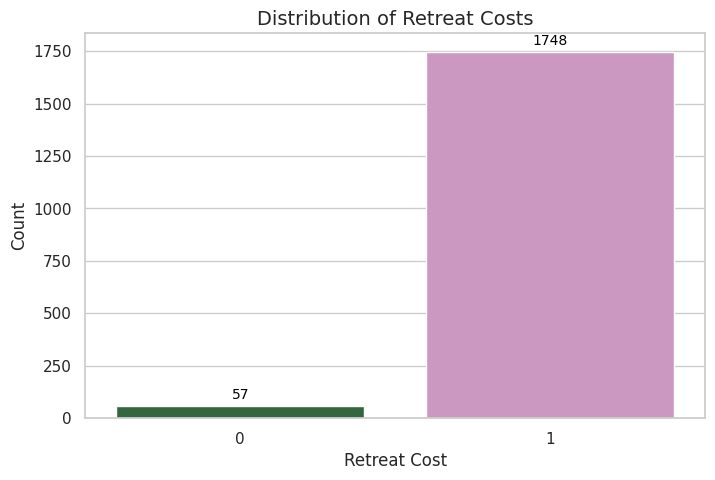

In [40]:
pokemon_df['Retreat_Cost'] = pokemon_df['Retreat'].astype(str).apply(lambda x: len(x.split()) if x != 'nan' else 0)

plt.figure(figsize=(8, 5))
ax=sns.countplot(data=pokemon_df, x='Retreat_Cost', palette='cubehelix')
plt.title('Distribution of Retreat Costs', fontsize=14)
plt.xlabel('Retreat Cost')
plt.ylabel('Count')
# Add data labels to the histogram bars
for p in ax.patches:
    height = p.get_height()
    # Only add a label if the bin has data and it's an actual bar patch
    if height > 0 and p.get_width() > 0:
        ax.annotate(
            f'{int(height)}', 
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='baseline', 
            fontsize=10, 
            color='black', 
            xytext=(0, 5), 
            textcoords='offset points'
        )
plt.show()


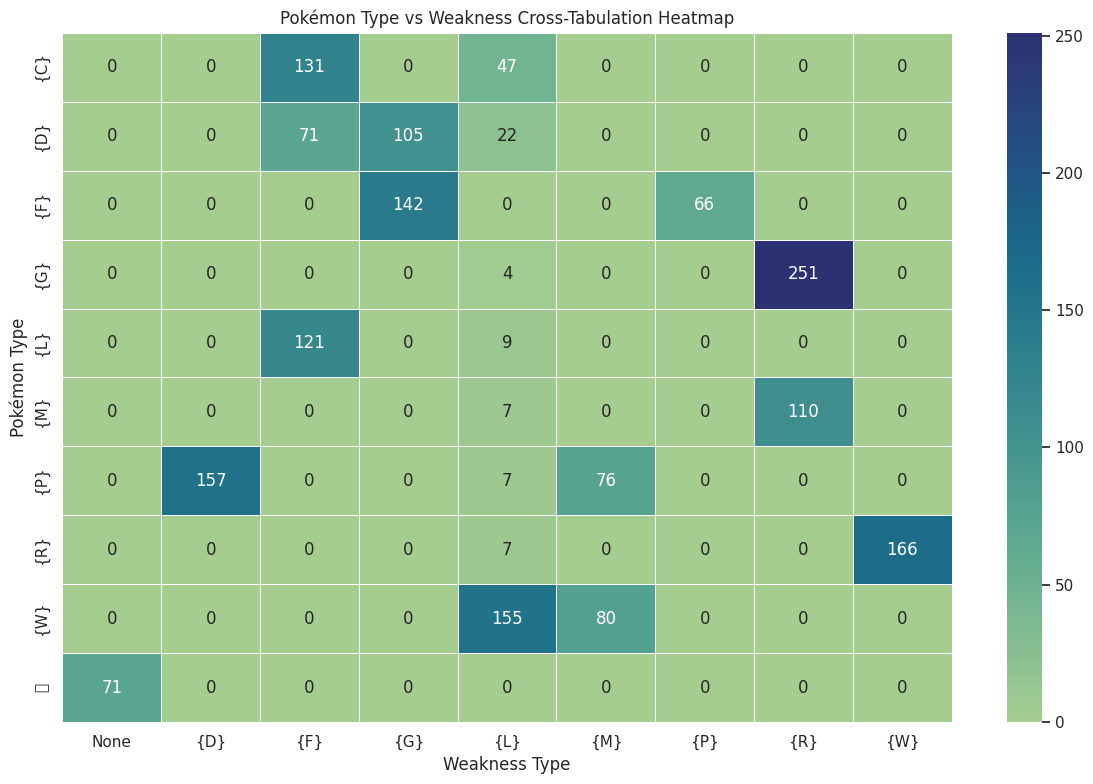

In [41]:
pokemon_df['Weakness_Clean'] = pokemon_df['Weakness'].fillna('None')
crosstab = pd.crosstab(pokemon_df['Type'], pokemon_df['Weakness_Clean'])

plt.figure(figsize=(12, 8))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='crest', cbar=True, linewidths=0.5)
plt.title('Pokémon Type vs Weakness Cross-Tabulation Heatmap')
plt.xlabel('Weakness Type')
plt.ylabel('Pokémon Type')
plt.tight_layout()
plt.show()

## 5. Energy Cards Analysis

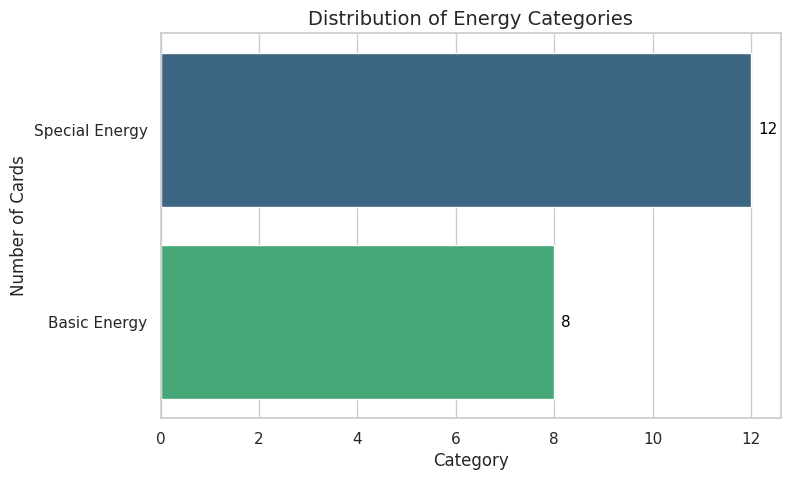

In [42]:
energy_df = df[df['Stage (Pokémon)/Type (Energy and Trainer)'].str.contains('Energy', case=False, na=False)].copy()

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=energy_df, y='Stage (Pokémon)/Type (Energy and Trainer)', order=energy_df['Stage (Pokémon)/Type (Energy and Trainer)'].value_counts().index, palette='viridis')
plt.title('Distribution of Energy Categories', fontsize=14)
plt.ylabel('Number of Cards')
plt.xlabel('Category')

# Add data labels
for p in ax.patches:
    width = p.get_width()
    # Check to ensure the bar has a valid value
    if width > 0:
        ax.annotate(
            f'{int(width)}', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left',          # Align text to the left of the coordinate
            va='center',        # Center vertically on the bar
            fontsize=11, 
            color='black', 
            xytext=(5, 0),      # Offset slightly to the right of the bar edge
            textcoords='offset points'
        )
plt.show()

## 6. Trainer Cards Analysis

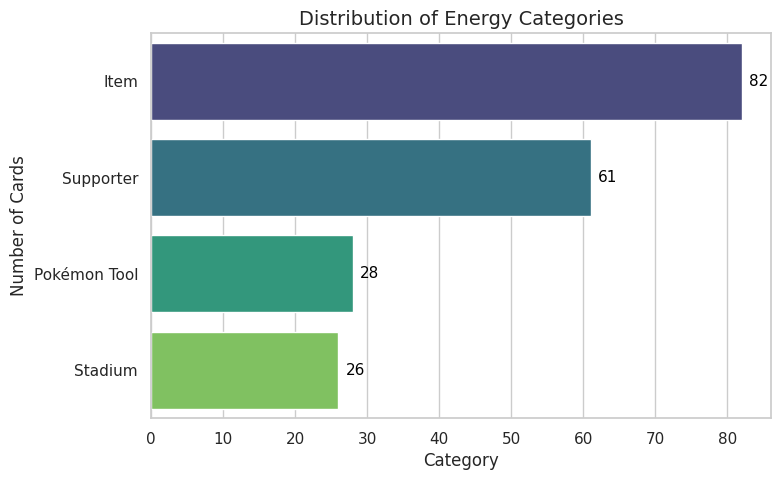

In [43]:
trainer_df = df[df['Stage (Pokémon)/Type (Energy and Trainer)'].str.contains('Item|Stadium|Supporter|Pokémon Tool', case=False, na=False)].copy()

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=trainer_df, y='Stage (Pokémon)/Type (Energy and Trainer)', order=trainer_df['Stage (Pokémon)/Type (Energy and Trainer)'].value_counts().index, palette='viridis')
plt.title('Distribution of Energy Categories', fontsize=14)
plt.ylabel('Number of Cards')
plt.xlabel('Category')

# Add data labels
for p in ax.patches:
    width = p.get_width()
    # Check to ensure the bar has a valid value
    if width > 0:
        ax.annotate(
            f'{int(width)}', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left',          # Align text to the left of the coordinate
            va='center',        # Center vertically on the bar
            fontsize=11, 
            color='black', 
            xytext=(5, 0),      # Offset slightly to the right of the bar edge
            textcoords='offset points'
        )
plt.show()

## 7. Effect Analysis

In [44]:
import pandas as pd
from collections import Counter
import re

copy_df = df.copy()

# 2. Extract the 'effect' column and join into one string
# Ensure you fill NaN values with empty strings
text = " ".join(copy_df['Effect Explanation'].astype(str).tolist()).lower()

# 3. Clean: Keep only letters/spaces, remove punctuation
# [^a-zA-Z\séÉ] means: "Remove everything that is NOT a-z, A-Z, space, or é/É"
text = re.sub(r'[^a-zA-Z\séÉ]', '', text)

# 4. Filter out 'Stopwords' (you can add more to this list)
stopwords = {'the', 'a', 'an', 'and', 'or', 'to', 'in', 'of', 'for', 'you', 'your', 'if', 'this'}
words = [w for w in text.split() if w not in stopwords]

# 5. Count
word_counts = Counter(words)

# Display top 20 words
print(word_counts.most_common())

[('pokémon', 1779), ('damage', 768), ('opponents', 641), ('nan', 541), ('from', 514), ('attack', 487), ('does', 427), ('deck', 411), ('is', 370), ('active', 356), ('energy', 352), ('turn', 346), ('card', 344), ('during', 322), ('cards', 311), ('hand', 296), ('each', 278), ('discard', 267), ('more', 242), ('put', 222), ('it', 221), ('attacks', 211), ('benched', 198), ('by', 188), ('may', 184), ('on', 182), ('any', 181), ('shuffle', 178), ('all', 177), ('basic', 174), ('into', 170), ('that', 167), ('as', 165), ('attached', 165), ('then', 160), ('use', 157), ('flip', 152), ('search', 147), ('next', 147), ('play', 146), ('them', 144), ('heads', 142), ('resistance', 139), ('weakness', 137), ('cant', 130), ('up', 121), ('their', 121), ('bench', 117), ('coin', 116), ('have', 106), ('has', 105), ('now', 99), ('once', 93), ('opponent', 92), ('out', 83), ('draw', 82), ('prevent', 79), ('done', 78), ('also', 77), ('reveal', 77), ('attach', 75), ('counters', 71), ('way', 69), ('both', 66), ('dont'

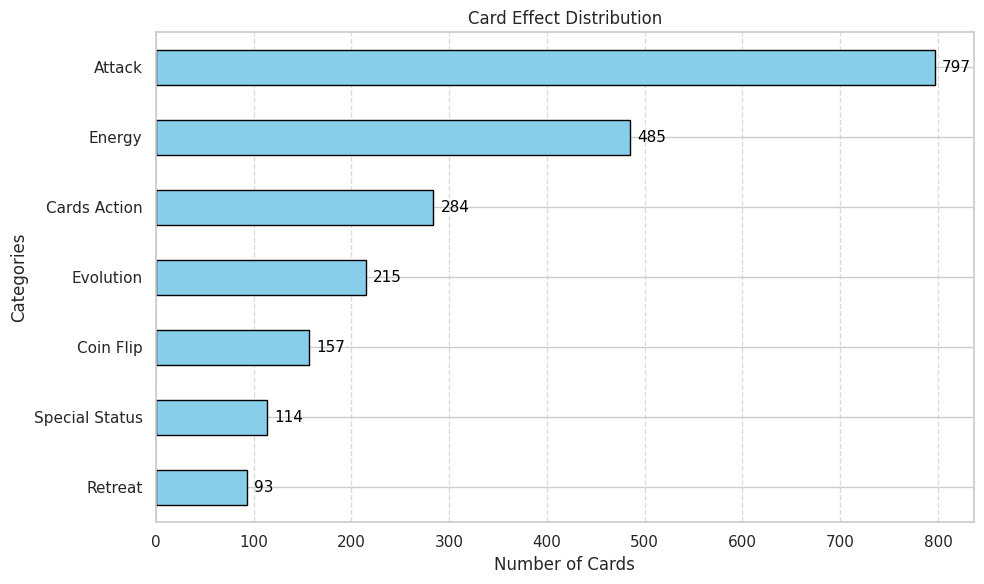

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define your categories and keywords
trigger_map = {
    'Attack': ['attack', 'attacks', 'damage', 'weakness', 'resistance'],
    'Retreat': ['retreat', 'switch'],
    'Evolution': ['evolve', 'evolves', 'stage', 'basic'],
    'Energy': ['energy', 'attach', 'attached', 'discard'],
    'Cards Action': ['draw', 'search', 'reveal', 'shuffle', 'look'],
    'Special Status': ['poisoned', 'burned', 'paralyzed', 'confused', 'asleep'],
    'Coin Flip': ['flip', 'coin', 'heads', 'tails']
}

# 2. Add the columns if they don't exist yet
for category, keywords in trigger_map.items():
    pattern = '|'.join(keywords)
    copy_df[category] = copy_df['Effect Explanation'].str.contains(pattern, case=False, na=False).astype(int)

# 3. Calculate counts
category_counts = copy_df[list(trigger_map.keys())].sum().sort_values(ascending=True)

# 4. Plot the data
fig, ax = plt.subplots(figsize=(10, 6))
category_counts.plot(kind='barh', color='skyblue', edgecolor='black', ax=ax)
ax.set_title('Card Effect Distribution')
ax.set_xlabel('Number of Cards')
ax.set_ylabel('Categories')
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Add annotations
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width)}', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center', 
            fontsize=11, 
            color='black', 
            xytext=(5, 0), 
            textcoords='offset points'
        )

plt.tight_layout()

## 8. Extension Analysis

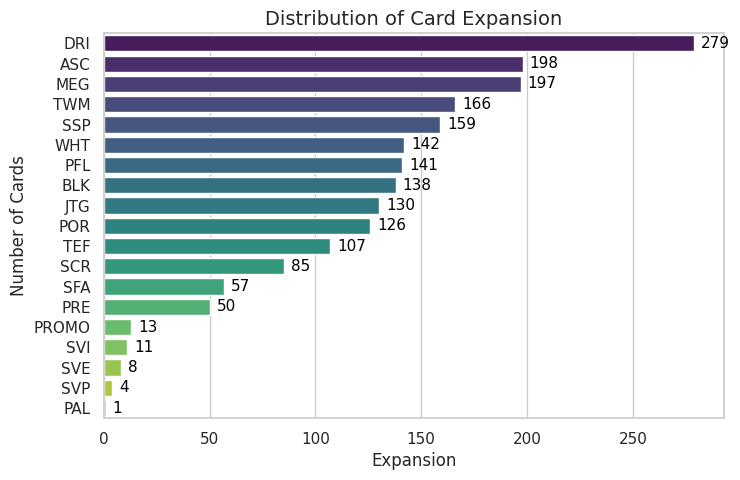

In [46]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, y='Expansion', order=df['Expansion'].value_counts().index, palette='viridis')
plt.title('Distribution of Card Expansion', fontsize=14)
plt.ylabel('Number of Cards')
plt.xlabel('Expansion')

# Add data labels
for p in ax.patches:
    width = p.get_width()
    # Check to ensure the bar has a valid value
    if width > 0:
        ax.annotate(
            f'{int(width)}', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left',          # Align text to the left of the coordinate
            va='center',        # Center vertically on the bar
            fontsize=11, 
            color='black', 
            xytext=(5, 0),      # Offset slightly to the right of the bar edge
            textcoords='offset points'
        )
plt.show()